# Bug fixes test: pyudlf

- ATENÇÃO: NÃO USAR PATHS COM ESPAÇOS

- Mencionar na documentação que nao tem suporte a macOS

In [1]:
from pyUDLF import run_calls as udlf
from pyUDLF.utils import inputType as it

#udlf.setBinaryPath("/opt/udlf/bin/udlf")
#udlf.setConfigPath("/opt/udlf/bin/config.ini")

input_data = it.InputType()
input_data.set_method_name("LHRR")
input_data.set_method_parameters("LHRR", k=18, l=1000, t=2)
input_data.set_task("UDL")
input_data.set_input_files("mpeg7/CFD.txt")
input_data.set_input_images_path("mpeg7/original")
input_data.set_lists_file("mpeg7/lists_mpeg7.txt")
input_data.set_classes_file("mpeg7/classes_mpeg7.txt")
input_data.set_dataset_size(1400)
input_data.set_output_file(True)
input_data.set_output_file_format("RK")
input_data.set_output_file_path("./output")
input_data.set_output_log_file_path("./log.txt")
input_data.set_effectiveness_eval(True)
input_data.set_effectiveness_compute_map(True)

output = udlf.run(input_data, get_output=True)

output.print_log()
#matrix = output.get_matrix() use with input_data.set_output_file_format("MATRIX")
rks = output.get_rks(top_k=100)
log = output.get_log()
print(log["MAP"]["After"])

[INFO] InputType initialized.
[WARNING] INPUT_FILE_FORMAT does not exist in parameters!
[INFO] UDLF binary and config found successfully.
[INFO] Running UDLF framework with config: /tmp/tmpjox7nmlq.ini
[WARNING] [LOG WARNING] *WARNING: You haven't declared INPUT_FILE_FORMAT!
[WARNING] [LOG WARNING] *WARNING: You haven't declared OUTPUT_RK_FORMAT!
[WARNING] [LOG WARNING] *WARNING: You haven't declared OUTPUT_HTML_RK_PER_FILE!
[INFO] pyUDLF execution complete!


Time       =  0.2227 s
P@4        = {'Before': '0.9786', 'After': '0.9795', 'Gain': '0.0912%'}
P@5        = {'Before': '0.9667', 'After': '0.9734', 'Gain': '0.6945%'}
P@10       = {'Before': '0.9061', 'After': '0.9556', 'Gain': '5.4627%'}
P@15       = {'Before': '0.8368', 'After': '0.9415', 'Gain': '12.5135%'}
P@20       = {'Before': '0.7559', 'After': '0.9161', 'Gain': '21.2058%'}
P@30       = {'Before': '0.5416', 'After': '0.6342', 'Gain': '17.1107%'}
P@50       = {'Before': '0.3462', 'After': '0.3904', 'Gain': '12.7754%'}
P@100      = {'Before': '0.1826', 'After': '0.1984', 'Gain': '8.6038%'}
Recall@4   = {'Before': '0.1957', 'After': '0.1959', 'Gain': '0.0912%'}
Recall@5   = {'Before': '0.2417', 'After': '0.2434', 'Gain': '0.6945%'}
Recall@10  = {'Before': '0.4531', 'After': '0.4778', 'Gain': '5.4627%'}
Recall@20  = {'Before': '0.7559', 'After': '0.9161', 'Gain': '21.2058%'}
Recall@40  = {'Before': '0.8444', 'After': '0.9668', 'Gain': '14.4948%'}
MAP        = {'Before': '0.8071', '

# List Params

In [2]:
# List all parameters and their current values
input_data.list_param()

# Full view with comments from config.ini
input_data.list_param_full()

# Info about a specific parameter
input_data.list_param_info("PARAM_LHRR_K")

# Info about all parameters of a method
input_data.list_method_info("LHRR")

# Get/set generic parameter
input_data.get_param("PARAM_LHRR_K")
input_data.set_param("PARAM_LHRR_K", 25)

# Add a parameter not in the original config
input_data.add_new_parameter("MY_CUSTOM_PARAM", "value")

# Save current config to file
input_data.write_config("my_config.ini")


...Listing parameters with values and withou comments...

#  PARAMETER_NAME = PARAMETER_VALUE
#  TBool = (TRUE|FALSE)
#  TUInt = (0-9)*
#  TFloat = ["+"|"-"] [0-9]* ["."] [0-9]+
UDL_TASK = UDL
UDL_METHOD = LHRR
SIZE_DATASET = 1400
INPUT_RK_FORMAT = NUM
MATRIX_TO_RK_SORTING = HEAP
NUM_INPUT_FUSION_FILES = 2
INPUT_FILES_FUSION_1 = input1.txt
INPUT_FILES_FUSION_2 = input2.txt
#INPUT_FILES_FUSION_* = input*.txt
INPUT_FILE = mpeg7/CFD.txt
INPUT_FILE_LIST = mpeg7/lists_mpeg7.txt
INPUT_FILE_CLASSES = mpeg7/classes_mpeg7.txt
INPUT_IMAGES_PATH = mpeg7/original
INPUT_MATRIX_TYPE = DIST
OUTPUT_FILE = TRUE
OUTPUT_FILE_FORMAT = RK
OUTPUT_MATRIX_TYPE = DIST
OUTPUT_FILE_PATH = ./output
OUTPUT_HTML_RK_SIZE = 20
OUTPUT_HTML_RK_COLORS = TRUE
OUTPUT_HTML_RK_BEFORE_AFTER = TRUE
OUTPUT_LOG_FILE_PATH = ./log.txt
EFFICIENCY_EVAL = TRUE
EFFECTIVENESS_EVAL = TRUE
EFFECTIVENESS_COMPUTE_PRECISIONS = TRUE
EFFECTIVENESS_COMPUTE_MAP = TRUE
EFFECTIVENESS_COMPUTE_RECALL = TRUE
EFFECTIVENESS_RECALLS_TO_COMPUTE = 4, 5

# Run With Config

In [3]:
output = udlf.runWithConfig(
    config_file="/home/bionda/Documents/The greatest time series libs of all time/teste/UDLF/bin/config.ini",
    get_output=True,
    compute_individual_gain=True,
    depth=100,
)

gain_list = output.get_individual_gain_list(sort=True)
gain_list

[INFO] UDLF binary and config found successfully.
[INFO] Running UDLF framework with config: /home/bionda/Documents/The greatest time series libs of all time/teste/UDLF/bin/config.ini
[INFO] pyUDLF execution complete!
[INFO] Individual gain computation completed successfully.



Calculating the gain for MAP with depth 100


[((0.7067, 1377), 1377),
 ((0.6991, 1378), 1378),
 ((0.6846, 195), 195),
 ((0.6794, 427), 427),
 ((0.6639, 742), 742),
 ((0.6619, 753), 753),
 ((0.6554, 117), 117),
 ((0.6526, 860), 860),
 ((0.6485, 899), 899),
 ((0.6465, 345), 345),
 ((0.6378, 710), 710),
 ((0.6331, 428), 428),
 ((0.6229, 741), 741),
 ((0.6196, 346), 346),
 ((0.6135, 1326), 1326),
 ((0.6108, 1048), 1048),
 ((0.5976, 709), 709),
 ((0.5922, 1332), 1332),
 ((0.5785, 522), 522),
 ((0.5763, 1260), 1260),
 ((0.5723, 1264), 1264),
 ((0.5684, 879), 879),
 ((0.5678, 1334), 1334),
 ((0.561, 862), 862),
 ((0.5607, 1320), 1320),
 ((0.5548, 1274), 1274),
 ((0.5499, 196), 196),
 ((0.5469, 191), 191),
 ((0.5449, 1090), 1090),
 ((0.5417, 861), 861),
 ((0.5416, 1330), 1330),
 ((0.5364, 355), 355),
 ((0.5315, 520), 520),
 ((0.5278, 1376), 1376),
 ((0.5201, 1335), 1335),
 ((0.5196, 1373), 1373),
 ((0.5106, 1261), 1261),
 ((0.5028, 1292), 1292),
 ((0.501, 199), 199),
 ((0.4905, 853), 853),
 ((0.4893, 382), 382),
 ((0.4859, 880), 880),
 (

# Show Ranked lists

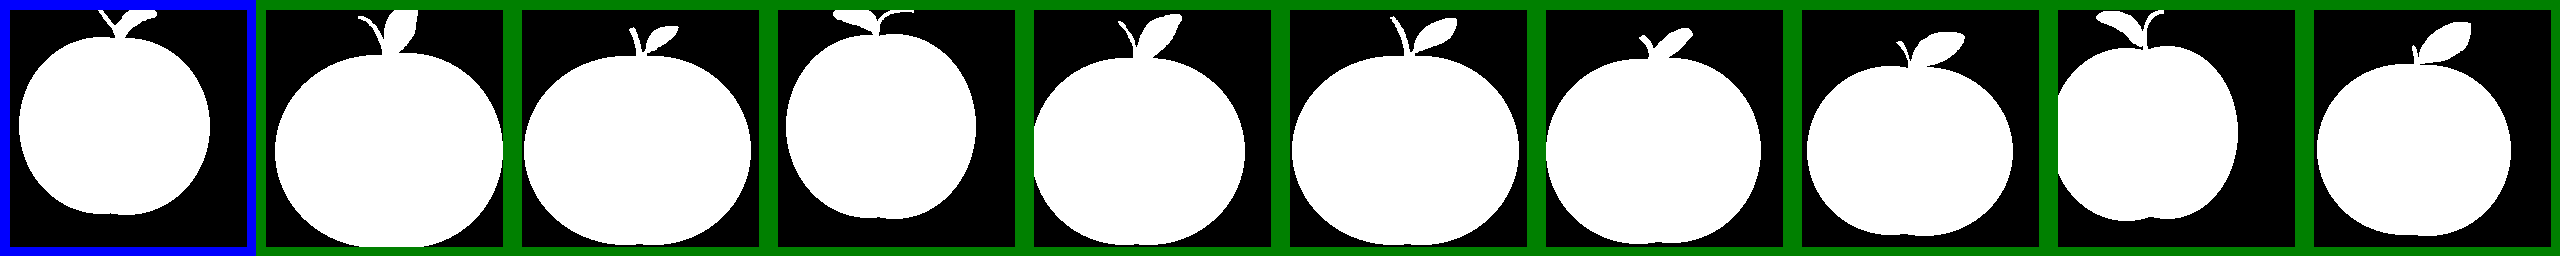

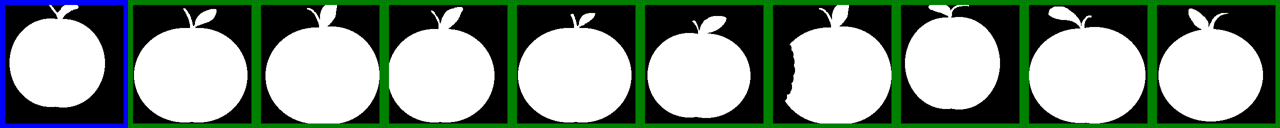

[INFO] Saved ranked list visualization at rk_query0.png


PosixPath('rk_query0.png')

In [4]:
from IPython.display import display

# Input ranked list (before re-ranking)
img = input_data.show_input_rk(line=0, rk_size=10)

display(img)

# Output ranked list (after re-ranking) — requires get_output=True and images_path set
img = output.show_rk(line=0, rk_size=10, images_shape=(128, 128))
display(img)

# Save to file
output.save_rk_img(line=0, rk_size=10, img_path="rk_query0.png")

# Grid Search

In [5]:
from pyUDLF.utils import gridSearch

input_data.set_method_name("CPRR")
input_data.set_effectiveness_eval(True)
input_data.set_effectiveness_compute_map(True)

best = gridSearch.find_best_param(
    input_type=input_data,
    method="CPRR",
    param_value="PARAM_CPRR_K",
    list_values=[5, 10, 15, 20, 25, 30],
)

[INFO] UDLF binary and config found successfully.
[INFO] Running UDLF framework with config: /tmp/tmpgkz5lzcg.ini
[WARNING] [LOG WARNING] *WARNING: You haven't declared INPUT_FILE_FORMAT!
[WARNING] [LOG WARNING] *WARNING: You haven't declared OUTPUT_RK_FORMAT!
[WARNING] [LOG WARNING] *WARNING: You haven't declared OUTPUT_HTML_RK_PER_FILE!
[INFO] pyUDLF execution complete!
[INFO] UDLF binary and config found successfully.
[INFO] Running UDLF framework with config: /tmp/tmpaz62bflt.ini
[WARNING] [LOG WARNING] *WARNING: You haven't declared INPUT_FILE_FORMAT!
[WARNING] [LOG WARNING] *WARNING: You haven't declared OUTPUT_RK_FORMAT!
[WARNING] [LOG WARNING] *WARNING: You haven't declared OUTPUT_HTML_RK_PER_FILE!
[INFO] pyUDLF execution complete!
[INFO] UDLF binary and config found successfully.
[INFO] Running UDLF framework with config: /tmp/tmp2jeogw22.ini
[WARNING] [LOG WARNING] *WARNING: You haven't declared INPUT_FILE_FORMAT!
[WARNING] [LOG WARNING] *WARNING: You haven't declared OUTPUT_

In [6]:
best

{'Recall@4': [(0.1968, 5),
  (0.1965, 10),
  (0.1959, 15),
  (0.1948, 20),
  (0.1941, 25),
  (0.1925, 30)],
 'Recall@5': [(0.2439, 10),
  (0.2435, 15),
  (0.2434, 5),
  (0.2422, 20),
  (0.2412, 25),
  (0.239, 30)],
 'Recall@10': [(0.4763, 20),
  (0.4755, 15),
  (0.4738, 25),
  (0.4735, 10),
  (0.4694, 30),
  (0.4658, 5)],
 'Recall@20': [(0.8979, 20),
  (0.8919, 25),
  (0.8913, 15),
  (0.881, 30),
  (0.8698, 10),
  (0.8136, 5)],
 'Recall@40': [(0.9477, 20),
  (0.9457, 15),
  (0.9394, 25),
  (0.9349, 10),
  (0.933, 30),
  (0.8865, 5)],
 'P@4': [(0.9839, 5),
  (0.9827, 10),
  (0.9795, 15),
  (0.9741, 20),
  (0.9704, 25),
  (0.9623, 30)],
 'P@5': [(0.9757, 10),
  (0.9739, 15),
  (0.9736, 5),
  (0.969, 20),
  (0.9647, 25),
  (0.956, 30)],
 'P@10': [(0.9525, 20),
  (0.9509, 15),
  (0.9476, 25),
  (0.9469, 10),
  (0.9389, 30),
  (0.9316, 5)],
 'P@15': [(0.9349, 20),
  (0.9296, 25),
  (0.9291, 15),
  (0.9182, 30),
  (0.9161, 10),
  (0.8868, 5)],
 'P@20': [(0.8979, 20),
  (0.8919, 25),
  (0.891

# Avaliação

In [9]:
from pyUDLF.utils import evaluation, readData

rks_before = readData.read_ranked_lists_file_numeric("mpeg7/CFD.txt", top_k=100)
classes = readData.read_classes("mpeg7/lists_mpeg7.txt", "mpeg7/classes_mpeg7.txt")

output = udlf.run(input_data, get_output=True)
rks_after = output.get_rks(top_k=100)

map_score, map_per_query = evaluation.compute_map(rks, classes, map_depth=100)
recall, recall_per_query = evaluation.compute_recall(rks, classes, r_depth=10)
precision, precision_per_query = evaluation.compute_precision(rks, classes, p_depth=5)

# Per-element gain between two ranked lists
gain_list = evaluation.compute_gain(
    before_rks=rks_before,
    after_rks=rks_after,
    classes_list=classes,
    depth=100,
    measure="MAP",
)
gain_list

[INFO] UDLF binary and config found successfully.
[INFO] Running UDLF framework with config: /tmp/tmpi5ipoz1h.ini
[WARNING] [LOG WARNING] *WARNING: You haven't declared INPUT_FILE_FORMAT!
[WARNING] [LOG WARNING] *WARNING: You haven't declared OUTPUT_RK_FORMAT!
[WARNING] [LOG WARNING] *WARNING: You haven't declared OUTPUT_HTML_RK_PER_FILE!
[INFO] pyUDLF execution complete!



Calculating the gain for MAP with depth 100


[(0.0093, 0),
 (0.1322, 1),
 (0.0634, 2),
 (0.0635, 3),
 (0.0575, 4),
 (0.077, 5),
 (0.0181, 6),
 (0.0304, 7),
 (0.0568, 8),
 (0.0, 9),
 (0.0386, 10),
 (0.0235, 11),
 (0.0045, 12),
 (0.0553, 13),
 (0.009, 14),
 (0.0296, 15),
 (0.0211, 16),
 (0.0557, 17),
 (0.0525, 18),
 (0.0024, 19),
 (0.1081, 20),
 (0.0288, 21),
 (0.0802, 22),
 (0.1178, 23),
 (0.2021, 24),
 (0.0302, 25),
 (0.031, 26),
 (0.1121, 27),
 (0.0352, 28),
 (0.3438, 29),
 (0.3446, 30),
 (0.3522, 31),
 (0.2781, 32),
 (0.0203, 33),
 (0.0, 34),
 (0.085, 35),
 (0.0674, 36),
 (0.1332, 37),
 (0.1627, 38),
 (0.1297, 39),
 (0.2499, 40),
 (0.1052, 41),
 (0.398, 42),
 (0.1765, 43),
 (0.1717, 44),
 (0.1313, 45),
 (0.1593, 46),
 (0.1086, 47),
 (0.219, 48),
 (0.2493, 49),
 (0.0967, 50),
 (0.0902, 51),
 (0.1292, 52),
 (0.0894, 53),
 (0.0775, 54),
 (0.0833, 55),
 (0.2166, 56),
 (0.1274, 57),
 (0.2251, 58),
 (0.2315, 59),
 (0.0049, 60),
 (0.057, 61),
 (0.0462, 62),
 (0.0, 63),
 (0.007, 64),
 (0.013, 65),
 (0.0143, 66),
 (0.0262, 67),
 (0.0273

In [10]:
udlf.build_udlf_from_source('/home/bionda/Desktop', branch='openmp')

NameError: name 'UDLF_REPO' is not defined